### **Mini Project 1**: House price prediction with *Linear regression*

First 5 rows of the dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
------------------------------
General dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Popul

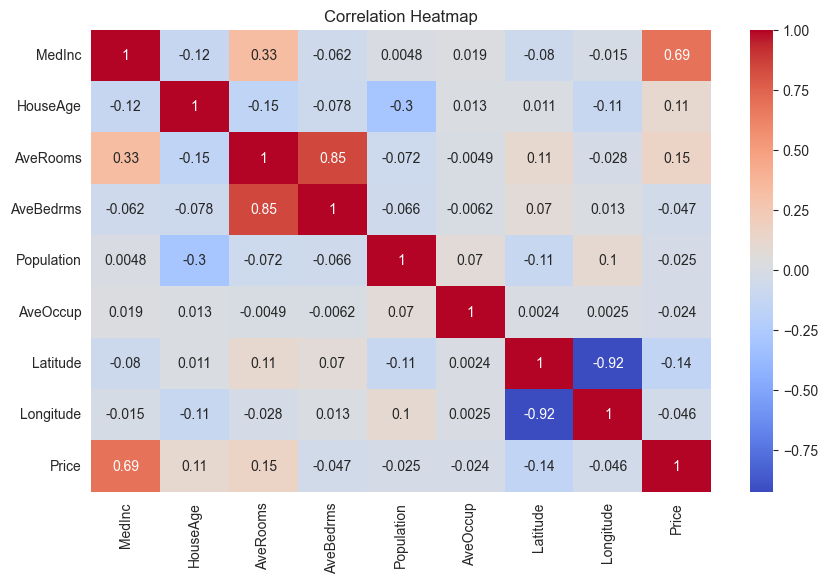

Training set shape: (16512, 8)
Test set shape: (4128, 8)
------------------------------
Finished training the Linear Regression model!
------------------------------

--- Model Coefficients ---
            Coefficient
AveBedrms      0.783145
MedInc         0.448675
HouseAge       0.009724
Population    -0.000002
AveOccup      -0.003526
AveRooms      -0.123323
Latitude      -0.419792
Longitude     -0.433708
------------------------------
Mean Absolute Error (MAE): 0.5332001304956555
Mean Squared Error:  0.5558915986952442
R-squared (R²): 0.575787706032451
------------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Make plots look nicer
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# EDA
print("First 5 rows of the dataset:")
print(df.head())
print("-" * 30)
print("General dataset information:")
df.info()
print("-" * 30)
print("Descriptive statistics:")
print(df.describe())
print("-" * 30)

df['Price'] = housing.target

# Visualize correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
# >> Note: The heatmap shows a strong positive correlation (0.69) between MedInc (Median Income) and Price.
# >> This suggests that median income is the most significant predictor of housing prices.

# Prepare data and train model
X = df.drop('Price', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, df['Price'], test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("-" * 30)

model = LinearRegression()
model.fit(X_train, y_train)
print("Finished training the Linear Regression model!")
print("-" * 30)

# Predict on test set
y_pred = model.predict(X_test)

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\n--- Model Coefficients ---")
print(coeff_df.sort_values('Coefficient', ascending=False))
print("-" * 30)

# Evaluate the model
print("Mean Absolute Error (MAE):", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_pred))
print("R-squared (R²):", metrics.r2_score(y_test, y_pred))
# >> Note: An R-squared of around 0.58 means that our model can explain approximately 58% of the variance in the housing prices.
print("-" * 30)

### **Mini Project 2**: Iris species classification with *Logistic regression*

First 5 rows of the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
------------------------------
Class distribution:
species name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
------------------------------


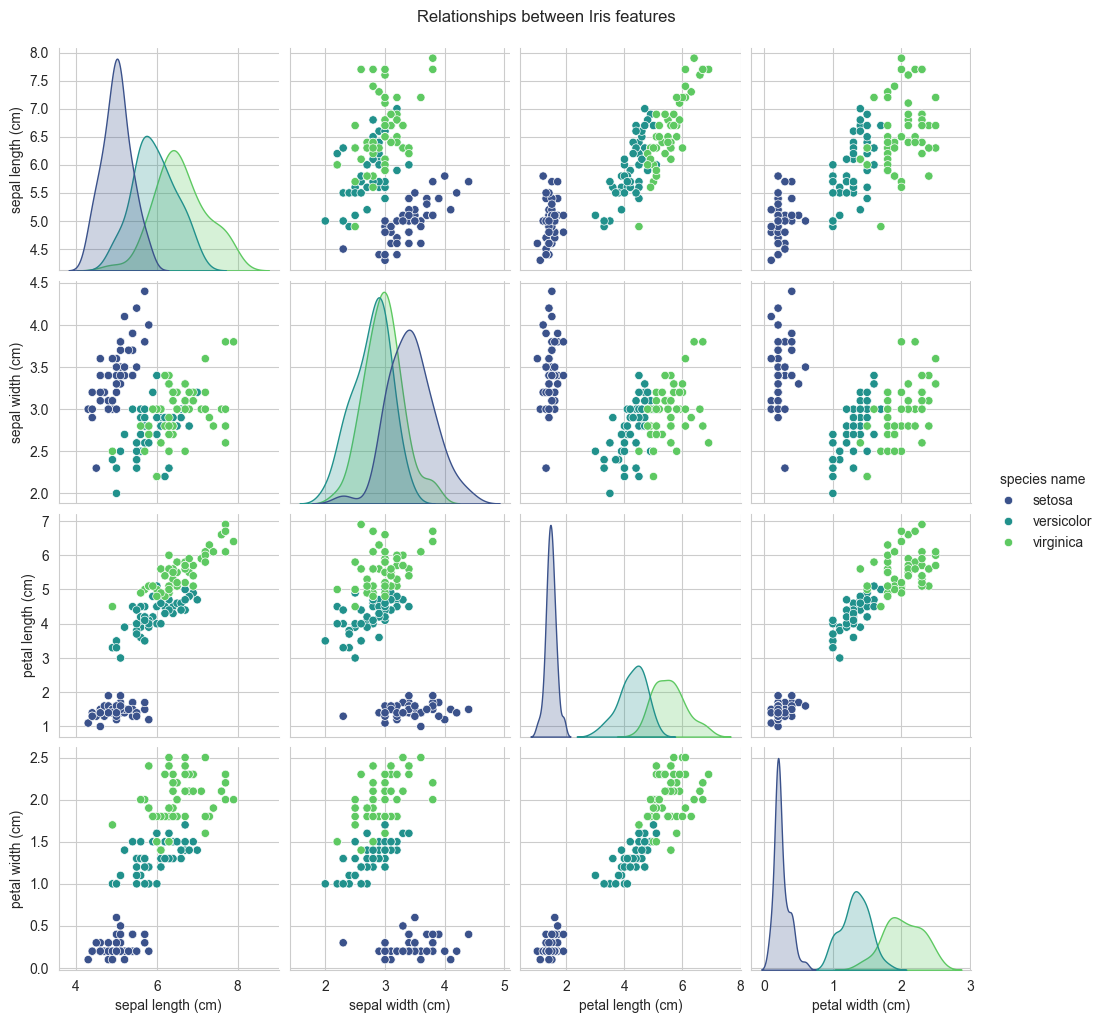

Finished training Logistic Regression model!
------------------------------
Accuracy score: 0.93
------------------------------
Confusion Matrix (numeric form):
 [[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]
------------------------------


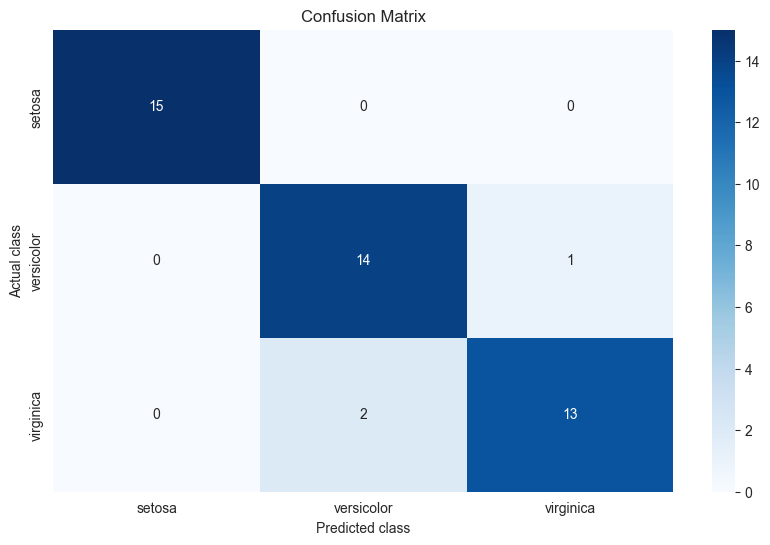

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

------------------------------


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# EDA
print("First 5 rows of the Iris dataset:")
print(df.head())
print("-" * 30)

df['species'] = iris.target
df['species name'] = iris.target_names[iris.target]

# Check class distribution
print("Class distribution:")
print(df['species name'].value_counts())
# >> Note: The dataset is perfectly balanced, with 50 samples per class.
print("-" * 30)

# Visualize relationships between features, colored by species
sns.pairplot(df.drop('species', axis=1), hue='species name', palette='viridis')
plt.suptitle("Relationships between Iris features", y=1.02)
plt.show()
# >> Note: Clusters of flowers are fairly well separated.
# Especially, 'setosa' (purple) is very easy to distinguish.
# 'versicolor' and 'virginica' show some overlap.

# Prepare data and train model
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print("Finished training Logistic Regression model!")
print("-" * 30)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {acc:.2f}")
print("-" * 30)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (numeric form):\n", cm)
print("-" * 30)

# Visualize the Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()

# Print a detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print("-" * 30)

### **Mini Project 3**: Customer Segmentation with *K-Means Clustering*

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
------------------------------


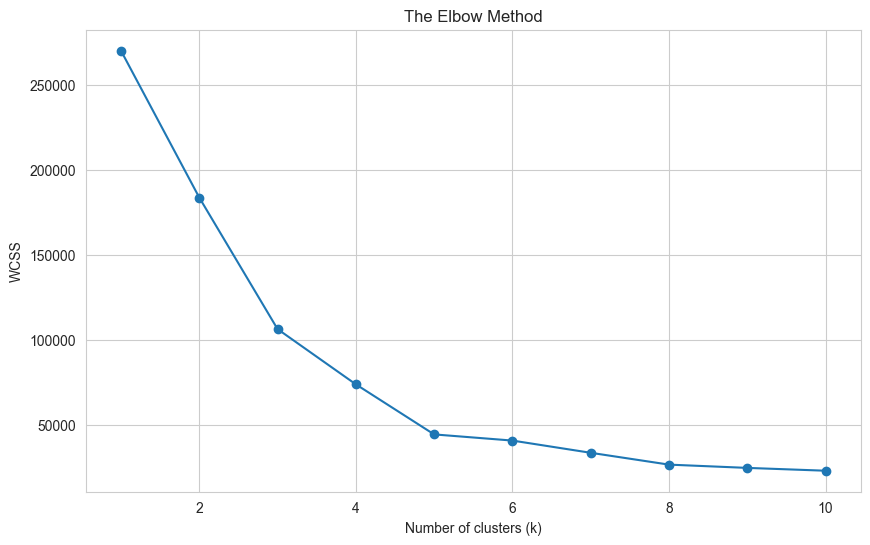

First 5 rows after assigning clusters:
   CustomerID  Gender  Age  Income  SpendingScore  Cluster
0           1    Male   19      15             39        4
1           2    Male   21      15             81        2
2           3  Female   20      16              6        4
3           4  Female   23      16             77        2
4           5  Female   31      17             40        4

--------------------------------------------------



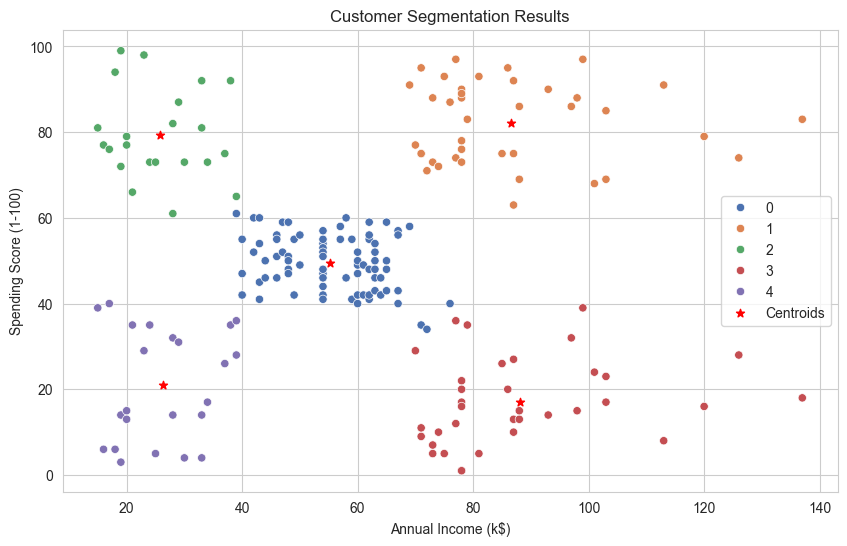

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_csv('data/Mall_Customers.csv')

print("First 5 rows of the dataset:")
print(df.head())
print("-" * 30)

# Rename for easier coding
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'SpendingScore' 
}, inplace=True)

# Select features for clustering
X = df[['Income', 'SpendingScore']]

# --- Finding the optimal number of clusters using the Elbow Method ---
wcss = [] # Within-Cluster-Sum-of-Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()
# >> Note: The "elbow" of the curve is the point where the rate of decrease in WCSS slows down significantly. In this plot, the elbow is clearly at k=5.

# Train model
model = KMeans(n_clusters=5, random_state=42, n_init='auto')
cluster_labels = model.fit_predict(X)
df['Cluster'] = cluster_labels

print('First 5 rows after assigning clusters:')
print(df.head())
print('\n' + '-'*50 + '\n')

# Visualize results
sns.scatterplot(data=df, x='Income', y='SpendingScore', hue='Cluster', palette='deep')

# Get cluster centroids from the trained model
centroids = model.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='*', label='Centroids')
plt.title('Customer Segmentation Results')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()
# >> Note: The visualization reveals 5 distinct customer segments